In [195]:
!pip install yfinance
!pip install pandas_datareader

In [196]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pandas_datareader.data import DataReader
import yfinance as yf
from pandas_datareader import data as pdr

# yf.pdr_override()

In [197]:
from datetime import datetime

tech_list = ['AAPL', 'GOOG', 'MSFT', 'AMZN']
end = datetime.now()
start = datetime(end.year-2, end.month, end.day)

In [198]:
for stock in tech_list:
    globals()[stock] = yf.download(stock, start, end)

/var/folders/24/z61d72zx27z5ml8twybhwmm40000gn/T/ipykernel_96973/2406771750.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  globals()[stock] = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed
/var/folders/24/z61d72zx27z5ml8twybhwmm40000gn/T/ipykernel_96973/2406771750.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  globals()[stock] = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed
/var/folders/24/z61d72zx27z5ml8twybhwmm40000gn/T/ipykernel_96973/2406771750.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  globals()[stock] = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed
/var/folders/24/z61d72zx27z5ml8twybhwmm40000gn/T/ipykernel_96973/2406771750.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to Tr

In [199]:
AAPL.columns = AAPL.columns.droplevel(1)
GOOG.columns = GOOG.columns.droplevel(1)
MSFT.columns = MSFT.columns.droplevel(1)
AMZN.columns = AMZN.columns.droplevel(1)

In [200]:
AAPL

Price,Close,High,Low,Open,Volume
Date,,,,,
2023-09-22,173.094528,175.362324,172.361716,172.975697,56725400
2023-09-25,174.372055,175.253422,172.460768,172.510286,46172700
2023-09-26,170.291992,173.500554,169.994899,173.124251,64588900
2023-09-27,168.776825,171.361509,167.410221,170.945584,66921800
2023-09-28,169.034317,170.361315,165.994089,167.697406,56294400
...,...,...,...,...,...
2025-09-15,236.699997,238.190002,235.029999,237.000000,42699500
2025-09-16,238.149994,241.220001,236.320007,237.179993,63421100
2025-09-17,238.990005,240.100006,237.729996,238.970001,46508000


In [201]:
company_list = [AAPL, GOOG, MSFT, AMZN]
company_name = ['APPLE', 'GOOGLE', 'MICROSOFT', 'AMAZON']


In [202]:
for company, com_name in zip(company_list, company_name):
    company['company_name'] = com_name

In [203]:
df = pd.concat(company_list, axis=0)

In [204]:
df.tail()

Price,Close,High,Low,Open,Volume,company_name
Date,,,,,,
2025-09-15,231.429993,233.729996,230.320007,230.630005,33243300,AMAZON
2025-09-16,234.050003,235.899994,232.229996,232.940002,38203900,AMAZON
2025-09-17,231.619995,234.300003,228.710007,233.770004,42815200,AMAZON
2025-09-18,231.229996,233.479996,228.789993,232.500000,37931700,AMAZON
2025-09-19,231.479996,234.160004,229.699997,232.369995,97810200,AMAZON


In [205]:
AAPL.describe()

Price,Close,High,Low,Open,Volume
count,500.000000,500.000000,500.000000,500.000000,5.000000e+02
mean,207.002407,208.921859,204.824229,206.750989,5.665268e+07
std,23.792337,23.956100,23.474800,23.764525,2.673242e+07
min,163.823578,165.213590,162.910139,164.171085,2.323470e+07
25%,187.389221,188.766840,185.591922,187.013255,4.238655e+07
50%,209.669441,212.154224,207.444047,209.589623,5.043100e+07
75%,226.849735,228.772784,224.646979,226.762146,6.194950e+07
max,258.103729,259.179926,256.718662,257.276679,3.186799e+08


In [206]:
AAPL.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 500 entries, 2023-09-22 to 2025-09-19
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Close         500 non-null    float64
 1   High          500 non-null    float64
 2   Low           500 non-null    float64
 3   Open          500 non-null    float64
 4   Volume        500 non-null    int64  
 5   company_name  500 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 27.3+ KB


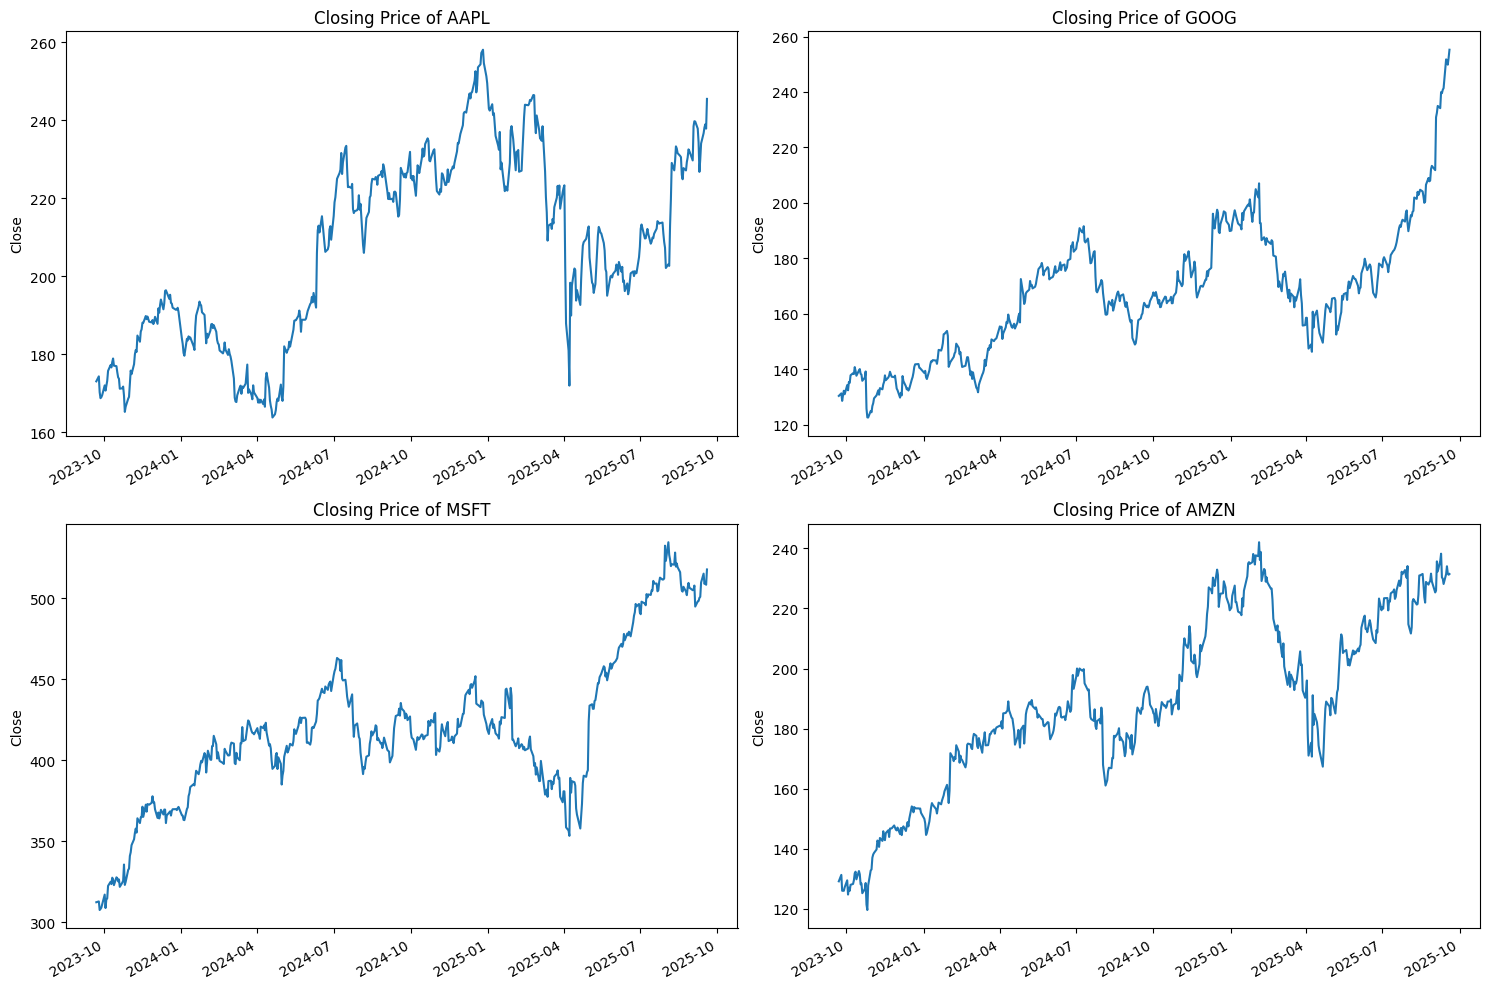

In [207]:
plt.figure(figsize=(15, 10))
plt.subplots_adjust(top=1.25, bottom=1.2)
for i, company in enumerate(company_list, 1):
    plt.subplot(2, 2, i)
    company['Close'].plot()
    plt.ylabel('Close')
    plt.xlabel(None)
    plt.title(f'Closing Price of {tech_list[i-1]}')

plt.tight_layout()


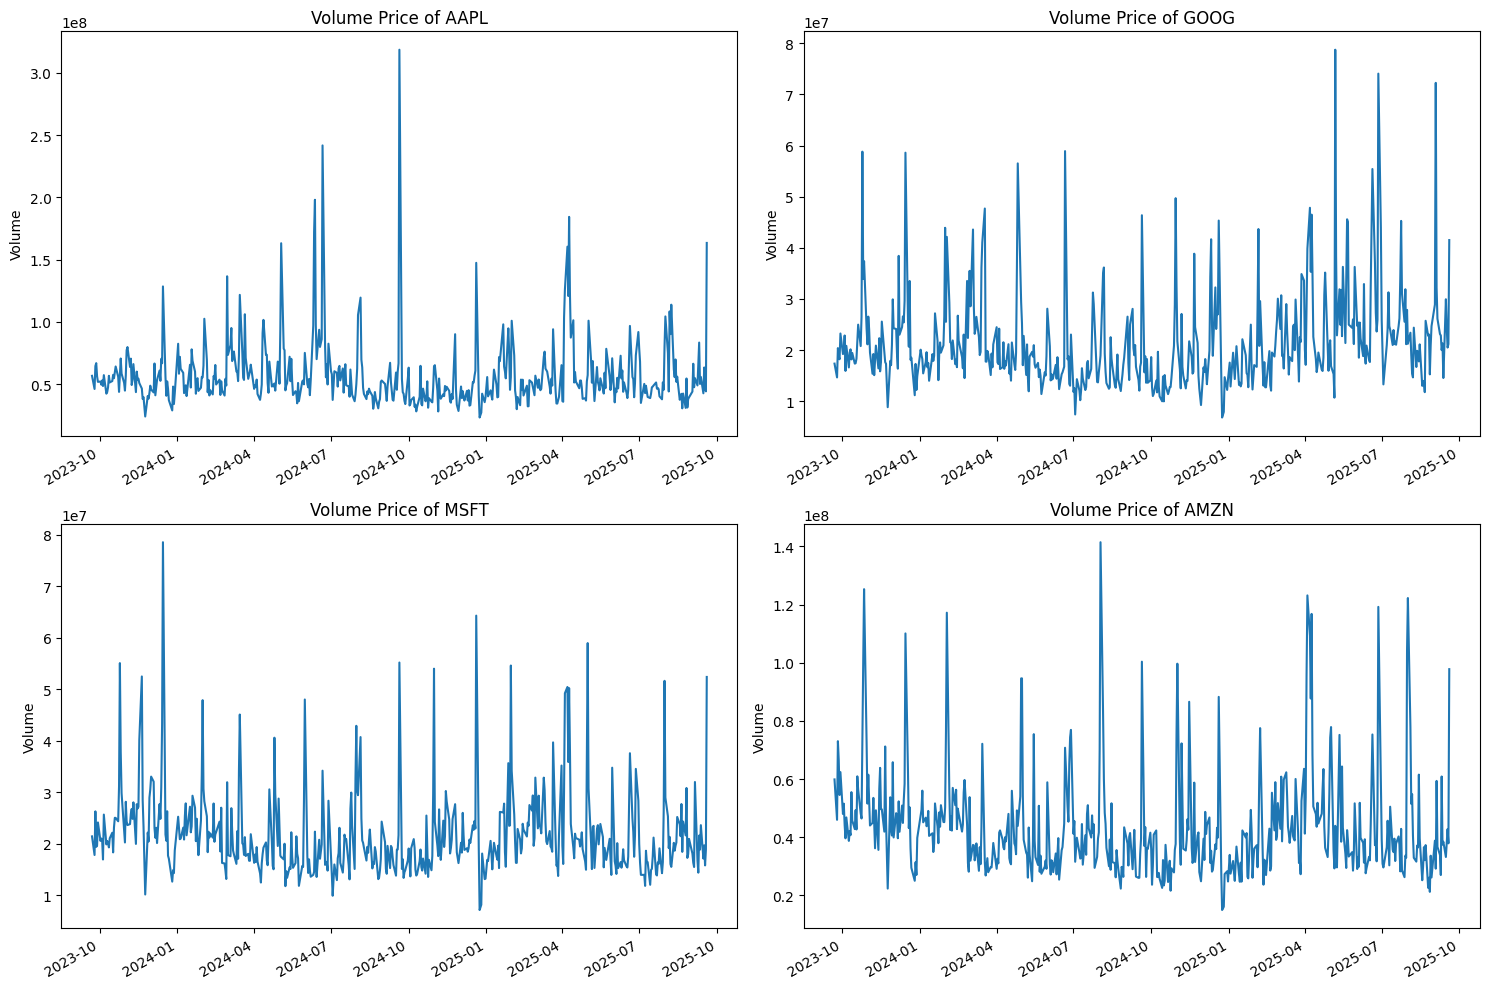

In [208]:
plt.figure(figsize=(15, 10))
plt.subplots_adjust(top=1.25, bottom=1.2)
for i, company in enumerate(company_list, 1):
    plt.subplot(2, 2, i)
    company['Volume'].plot()
    plt.ylabel('Volume')
    plt.xlabel(None)
    plt.title(f'Volume Price of {tech_list[i-1]}')

plt.tight_layout()

### Модель MA скользящее среднее

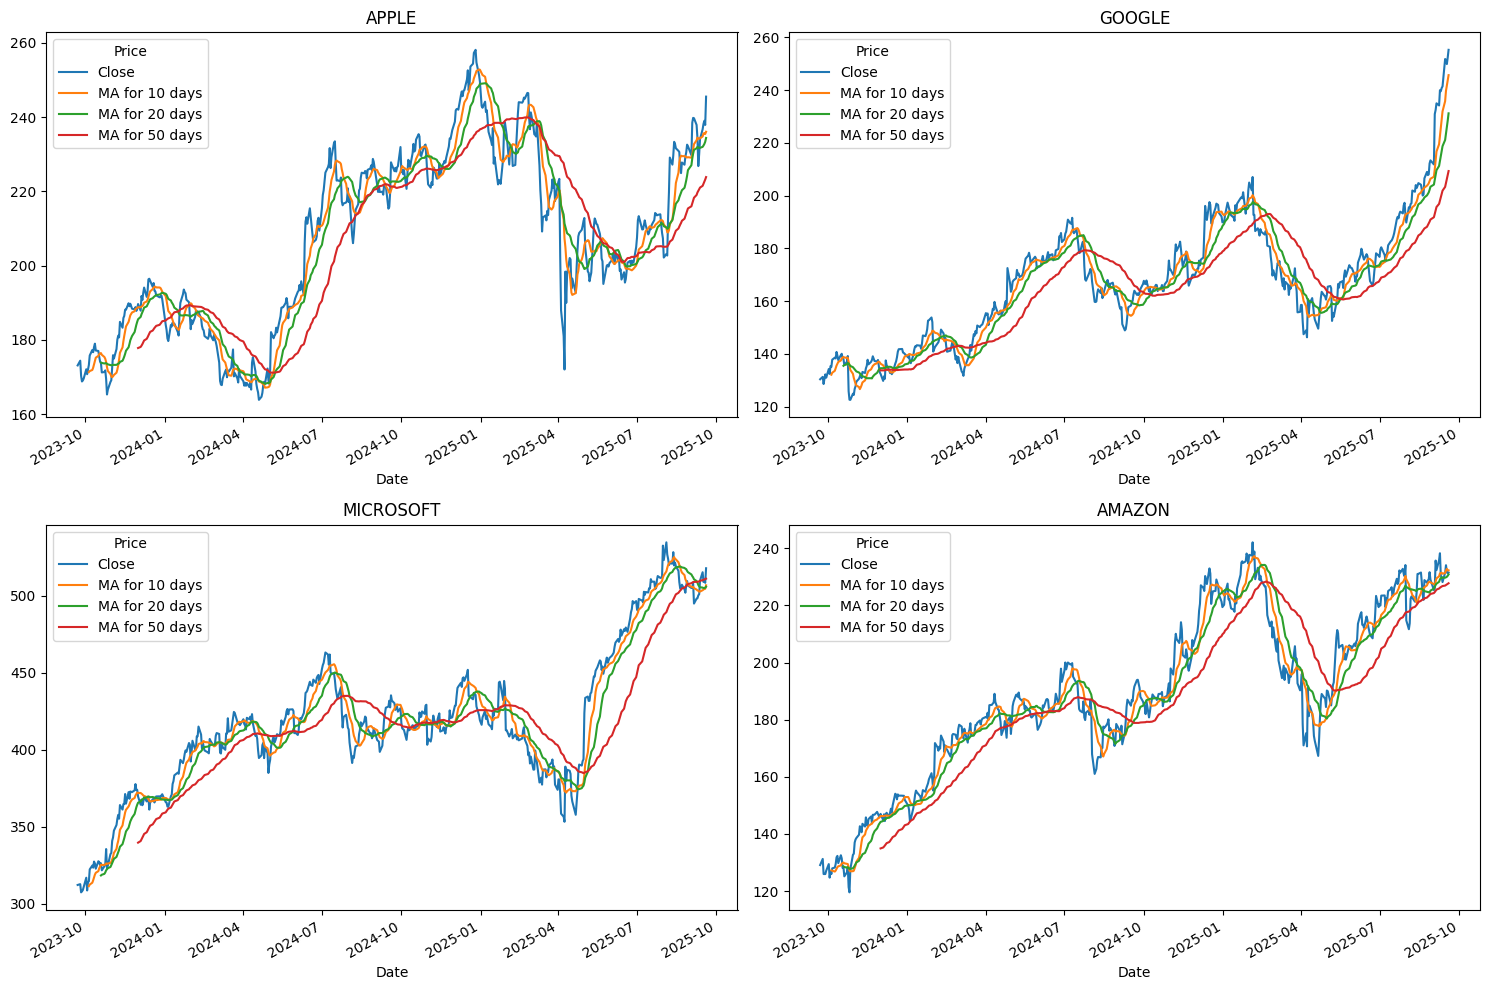

In [209]:
ma_day = [10, 20, 50]
for ma in ma_day:
    for company in company_list:
        column_name = f'MA for {ma} days'
        company[column_name] = company['Close'].rolling(ma).mean()

fig, axes = plt.subplots(nrows=2, ncols=2)
fig.set_figheight(10)
fig.set_figwidth(15)

AAPL[['Close', 'MA for 10 days', 'MA for 20 days', 'MA for 50 days']].plot(ax=axes[0,0])
axes[0,0].set_title('APPLE')

GOOG[['Close', 'MA for 10 days', 'MA for 20 days', 'MA for 50 days']].plot(ax=axes[0,1])
axes[0,1].set_title('GOOGLE')

MSFT[['Close', 'MA for 10 days', 'MA for 20 days', 'MA for 50 days']].plot(ax=axes[1,0])
axes[1,0].set_title('MICROSOFT')

AMZN[['Close', 'MA for 10 days', 'MA for 20 days', 'MA for 50 days']].plot(ax=axes[1,1])
axes[1,1].set_title('AMAZON')

fig.tight_layout()

### Дневные изменения

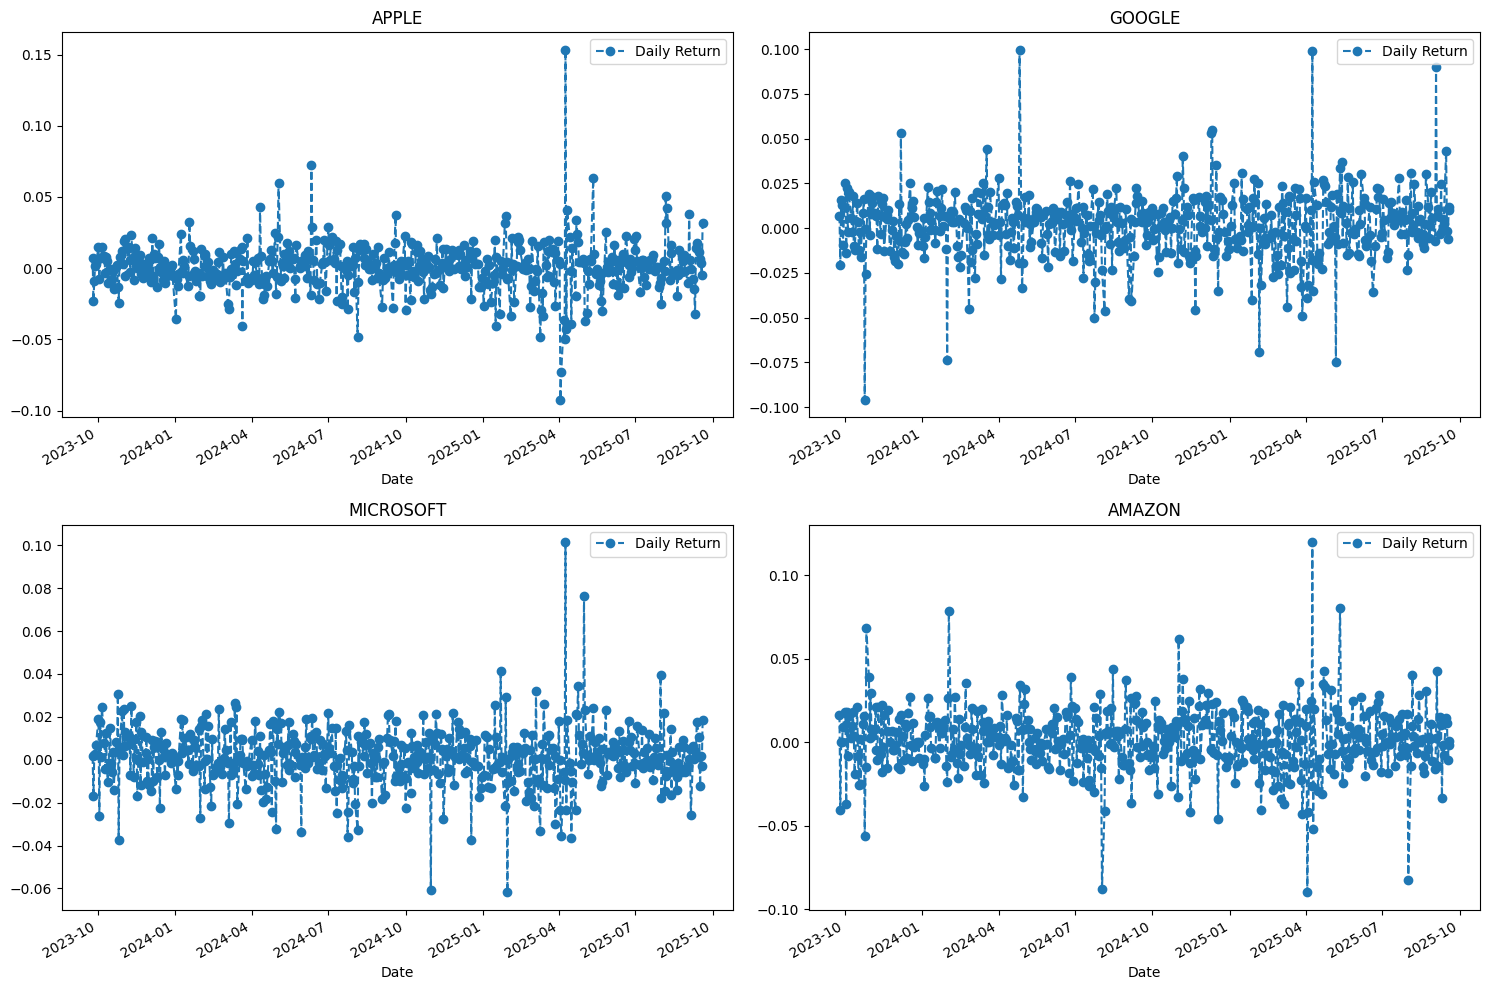

In [210]:
for company in company_list:
    company['Daily Return'] = company['Close'].pct_change()

fig, axes = plt.subplots(nrows=2, ncols=2)
fig.set_figheight(10)
fig.set_figwidth(15)

AAPL['Daily Return'].plot(ax=axes[0,0], legend=True, linestyle ='--', marker='o')
axes[0,0].set_title('APPLE')

GOOG['Daily Return'].plot(ax=axes[0,1], legend=True, linestyle ='--', marker='o')
axes[0,1].set_title('GOOGLE')

MSFT['Daily Return'].plot(ax=axes[1,0], legend=True, linestyle ='--', marker='o')
axes[1,0].set_title('MICROSOFT')

AMZN['Daily Return'].plot(ax=axes[1,1], legend=True, linestyle ='--', marker='o')
axes[1,1].set_title('AMAZON')

fig.tight_layout()

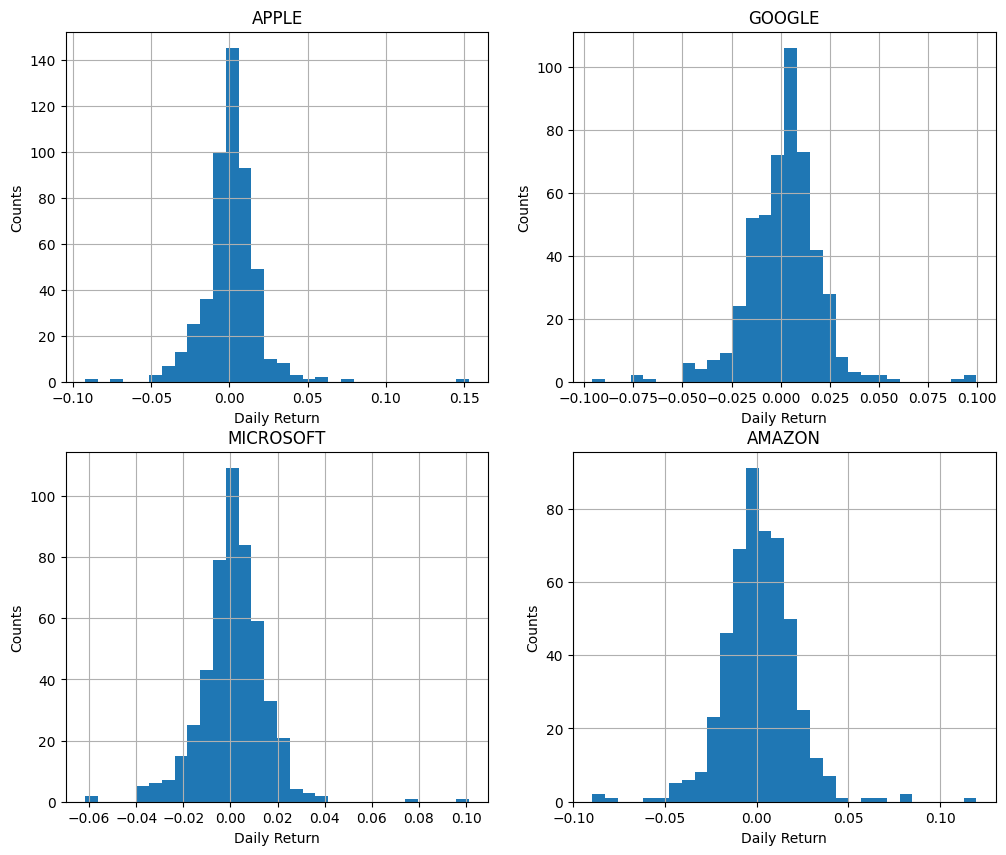

In [213]:
plt.figure(figsize=(12,10))
for i, company in enumerate(company_list, 1):
    plt.subplot(2, 2, i)
    company['Daily Return'].hist(bins=30)
    plt.xlabel('Daily Return')
    plt.ylabel('Counts')
    plt.title(f'{company_name[i-1]}')

fig.tight_layout()

In [216]:
closing_df = yf.download(tech_list, start=start, end=end)['Close']

/var/folders/24/z61d72zx27z5ml8twybhwmm40000gn/T/ipykernel_96973/2746958638.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  closing_df = yf.download(tech_list, start=start, end=end)['Close']
[*********************100%***********************]  4 of 4 completed


In [218]:
tech_rets = closing_df.pct_change()
tech_rets.head(10)

Ticker,AAPL,AMZN,GOOG,MSFT
Date,,,,
2023-09-22,NaN,NaN,NaN,NaN
2023-09-25,0.007380,0.016651,0.007009,0.001672
2023-09-26,-0.023398,-0.040299,-0.020580,-0.017006
2023-09-27,-0.008898,0.000000,0.015527,0.002082
2023-09-28,0.001526,0.000000,0.012703,0.002718
2023-09-29,0.003047,0.009049,-0.009615,0.006727
2023-10-02,0.014836,0.018408,0.025180,0.019161
2023-10-03,-0.007770,-0.036614,-0.013834,-0.026134
2023-10-04,0.007309,0.018281,0.022280,0.017773


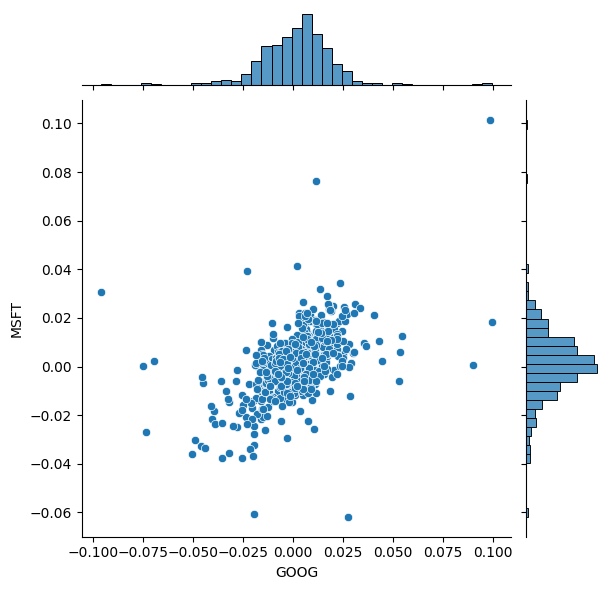

In [220]:
sns.jointplot(x='GOOG', y='MSFT', data=tech_rets, kind='scatter')
plt.show()

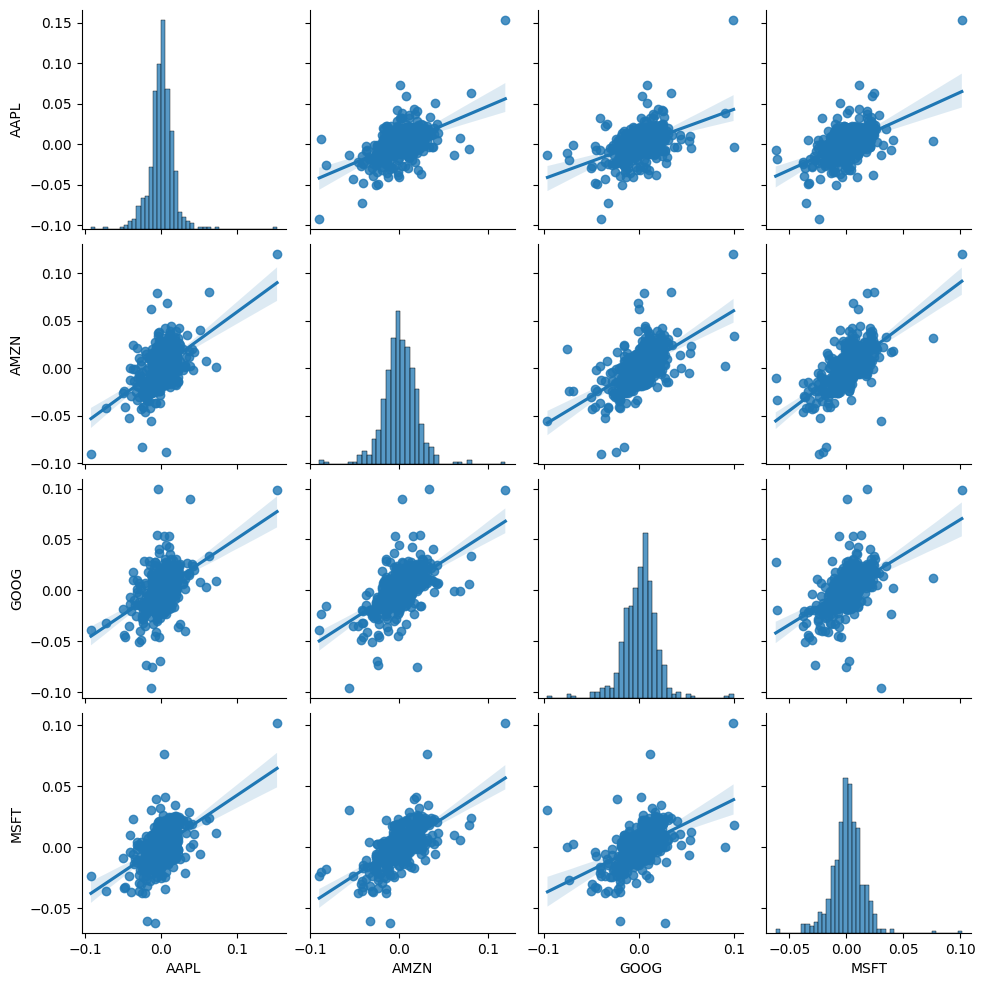

In [222]:
sns.pairplot(tech_rets, kind='reg')
plt.show()

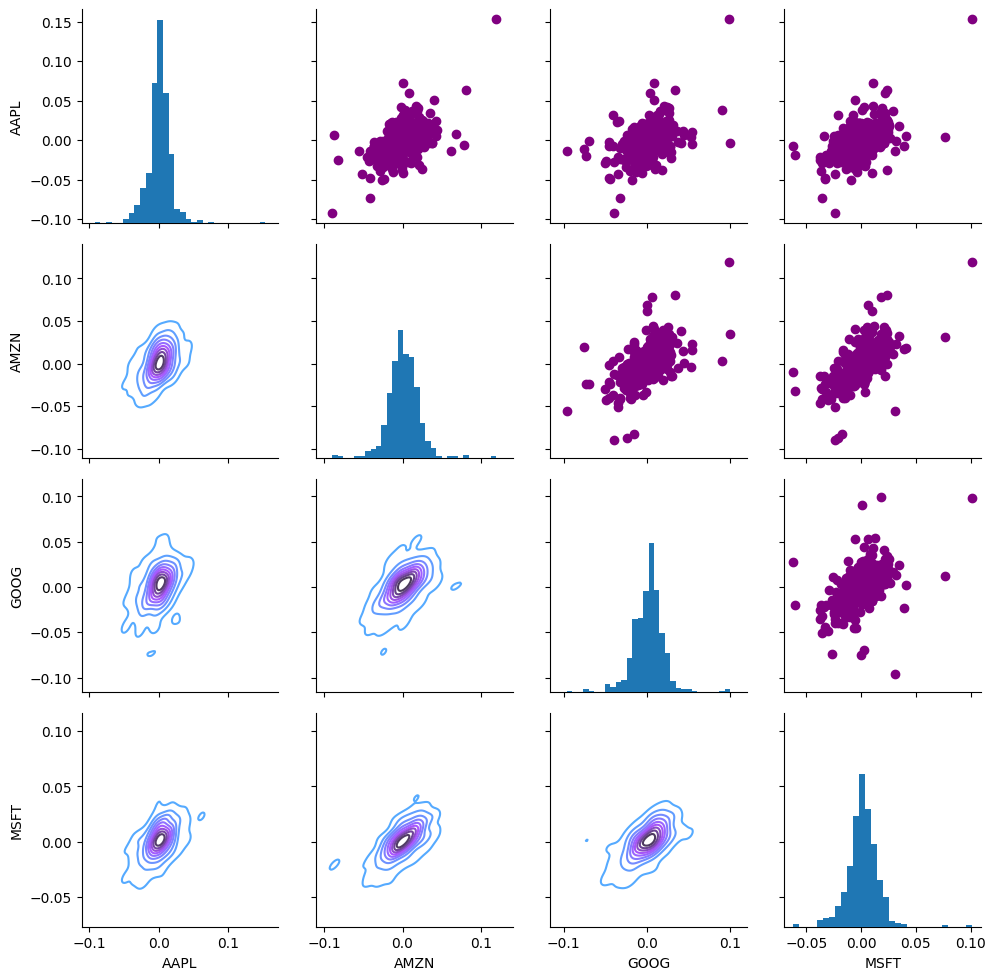

In [225]:
return_fig = sns.PairGrid(tech_rets.dropna())
return_fig.map_upper(plt.scatter, color='purple')
return_fig.map_lower(sns.kdeplot, cmap='cool_d')
return_fig.map_diag(plt.hist, bins=30)
plt.show()


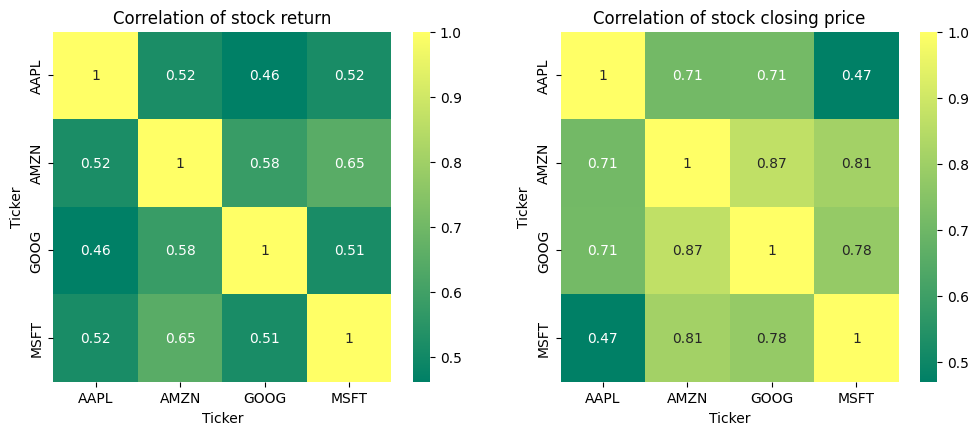

In [230]:
plt.figure(figsize=(12, 10))
plt.subplot(2,2,1)
sns.heatmap(tech_rets.corr(), annot=True, cmap='summer')
plt.title('Correlation of stock return')

plt.subplot(2,2,2)
sns.heatmap(closing_df.corr(), annot=True, cmap='summer')
plt.title('Correlation of stock closing price')

fig.tight_layout()